<h1> Lab 5: Classifying Brain Tumors from MRI Images </h1>

In this lab, we will learn to classify four types of brain images by:

- training a Convolutional Neural Network (CNN)
- applying transfer learning using pre-trained models, fine-tuning, and re-training the final classification layers



We will be using the Brain Tumor MRI Dataset provided on Kaggle. This dataset includes MRI images categorized into four classes:

- Glioma
- Meningioma
- Pituitary
- No tumor

For more information about the dataset, please visit:
https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset/data. We will be loading the dataset later on using the Python package `kagglehub`.

## Library imports


In [1]:
!pip install opencv-python

In [2]:
# Please be free to add more libraries if needed
import pandas as pd
import numpy as np
from glob import glob
import matplotlib.pyplot as plt # basic plotting
import seaborn as sns # additional plotting functionality
from sklearn.model_selection import train_test_split # Train test split
import torch # torch
from torchvision import transforms # transform is used for data pre-processing
from torch.utils import data as Data
from torch.utils.data import Dataset # for dataset construction
import torch.optim as optim
from PIL import Image
import numpy as np
import imageio
import cv2 as cv # cv2
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline
import random # For randomizing
from collections import Counter
import re
import sklearn
from sklearn.utils.class_weight import compute_class_weight
import os
import cv2

# from google.colab.patches import cv2_imshow
from tqdm.notebook import tqdm
from PIL import Image
import os

import cv2
import numpy as np
from collections import Counter
import re
import kagglehub

## Task 1 (10 points)

---


**1.1. Load the dataset (8 points)**

---

Read the data and construct the dataframe. In this lab, we will only be using the training data from the dataset.

In [3]:
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [4]:
path = f"{path}/Training"
class_names = os.listdir(path)

In [5]:
# YOUR CODE HERE
# I am going to start by reading all 4 types of data in different datasets

data = []
for name in class_names:
	for img_path in os.listdir(f"{path}/{name}"):
		total_path = os.path.join(path, name, img_path)
		current_row = {"image_path": total_path, "label": name}
		data.append(current_row)

# Constructing the final dataframe
df = pd.DataFrame(data)

display(df.head())

# print the number of samples in each class
display(df["label"].value_counts())

,image_path,label
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary


,count
label,
pituitary,1400
notumor,1400
meningioma,1400
glioma,1400


**1.2. Create artificial class imbalance (2 points)**

---

Pituitary tumors are less common than gliomas or meningiomas. To better simulate the scenario where you have limited access to such images, only include 600 pituitary tumor images in your Dataframe.

In [6]:
# YOUR CODE HERE
# Only keep 600 pituitary tumor samples to balance the dataset
pituitary_samples = df[df["label"] == "pituitary"]
other_samples = df[df["label"] != "pituitary"]

balanced_pituitary_samples = pituitary_samples.sample(n=600, random_state=3)

balanced_df = pd.concat([balanced_pituitary_samples, other_samples], ignore_index=True)

# replace df so that the garbage collector can free up memory
df = balanced_df

display(balanced_df["label"].value_counts())

,count
label,
notumor,1400
meningioma,1400
glioma,1400
pituitary,600


## Task 2 (15 points)

---

Split into train-validation-test set and data visualization, and avoid that imgaes from a same person appear simutaneously in training and testing set.

In [7]:
# Task 2: Manually split the dataset into training (~70%), validation (~10%), and testing (~20%)
#
# Do not use `train_test_split`. Instead, implement your own split logic using numpy.
# You should shuffle the indices, compute split sizes, and apply your own `get_split()` function.
#
# Input to get_split():
#   - df: dataframe including image paths and labels
#   - index_list: indices to extract
#
# Output:
#   - subset: dataframe including only the given indices

# YOUR CODE HERE
all_indices = np.arange(len(balanced_df))

# Shuffle the indices
np.random.shuffle(all_indices)

# Compute split sizes
train_size = int(0.7 * len(balanced_df))
val_size = int(0.1 * len(balanced_df))
test_size = len(balanced_df) - train_size - val_size

# log the split sizes to verify
print(f"Train size: {train_size}, Validation size: {val_size}, Test size: {test_size}")

# get the indices for each split
train_indices = all_indices[:train_size]
val_indices = all_indices[train_size:train_size + val_size]
test_indices = all_indices[train_size + val_size:]

# Get the indices of the dataframe
def get_split(df, indices):
	"""
	Extracts a subset of image paths and labels using the given indices.

	Args:
		df: dataframe including image paths and labels
		index_list: indices to extract

	Returns:
		subset: dataframe including only the given indices
	"""

	return df.iloc[indices].reset_index(drop=True)


train_df = get_split(balanced_df, train_indices)
val_df = get_split(balanced_df, val_indices)
test_df = get_split(balanced_df, test_indices)

# log the number of samples in each split to verify
print("Training set class distribution:")
print(train_df["label"].value_counts())
print("\nValidation set class distribution:")
print(val_df["label"].value_counts())
print("\nTesting set class distribution:")
print(test_df["label"].value_counts())

Train size: 3360, Validation size: 480, Test size: 960
Training set class distribution:
label
notumor       988
glioma        974
meningioma    972
pituitary     426
Name: count, dtype: int64

Validation set class distribution:
label
meningioma    146
notumor       143
glioma        140
pituitary      51
Name: count, dtype: int64

Testing set class distribution:
label
glioma        286
meningioma    282
notumor       269
pituitary     123
Name: count, dtype: int64


In [8]:
display(train_df)

,image_path,label
0,/kaggle/input/brain-tumor-mri-dataset/Training...,meningioma
1,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
2,/kaggle/input/brain-tumor-mri-dataset/Training...,meningioma
3,/kaggle/input/brain-tumor-mri-dataset/Training...,notumor
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
...,...,...
3355,/kaggle/input/brain-tumor-mri-dataset/Training...,meningioma
3356,/kaggle/input/brain-tumor-mri-dataset/Training...,notumor
3357,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
3358,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary


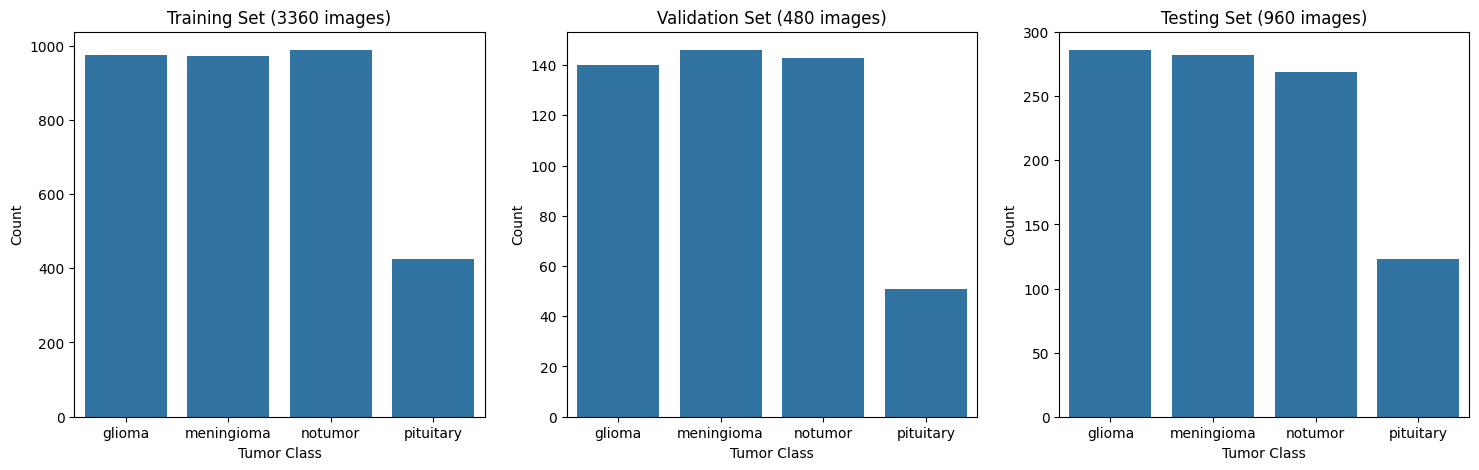

In [9]:
# Plot class distribution as bar plots for each of the three splits
# (training, validation, testing) using one bar chart per split

# YOUR CODE GOES HERE
# Set up a figure with 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define the order so the colors and bars match across all three plots
class_order = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Training Set Plot
sns.countplot(data=train_df, x='label', ax=axes[0], order=class_order)	
axes[0].set_title(f'Training Set ({len(train_df)} images)')
axes[0].set_xlabel('Tumor Class')
axes[0].set_ylabel('Count')

# Validation Set Plot
sns.countplot(data=val_df, x='label', ax=axes[1], order=class_order)
axes[1].set_title(f'Validation Set ({len(val_df)} images)')
axes[1].set_xlabel('Tumor Class')
axes[1].set_ylabel('Count')

# Testing Set Plot
sns.countplot(data=test_df, x='label', ax=axes[2], order=class_order)
axes[2].set_title(f'Testing Set ({len(test_df)} images)')
axes[2].set_xlabel('Tumor Class')
axes[2].set_ylabel('Count')

# Adjust layout so the labels don't overlap, then show the plot
plt.show()

## Task 3 (25 points)

---


**Task 3.1. Construct the dataset for Pytorch (10 points)**

---

In this task, you will create a custom Dataset class that:
 - Loads images lazily from file paths
 - Applies any specified transformations
 - Returns one-hot encoded labels for training

We will convert images to grayscale MRI slices in this task.

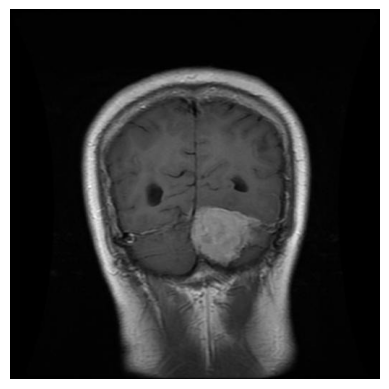

Image shape: (512, 512, 3)


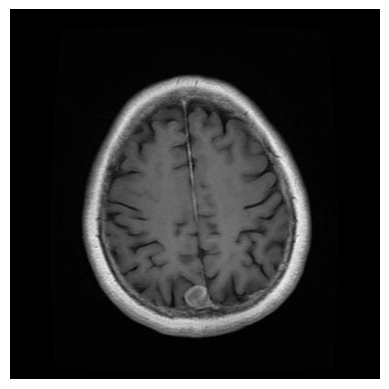

Image shape: (512, 512, 3)


In [10]:
# Getting a peak of what the images look like


image = cv2.imread(train_df["image_path"][0])
image_color = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_color); plt.axis('off') # Hide axes for better visualization
plt.show()
print("Image shape:", image.shape)	

image = cv2.imread(train_df["image_path"][100])	
image_color = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_color); plt.axis('off') # Hide axes for better visualization
plt.show()

print("Image shape:", image.shape)


In [11]:
class MRIDataset(Dataset):
	"""
	PyTorch Dataset class for MRI brain images dataset.

	Args:
		df (DataFrame): Dataframe containing file paths to images and corresponding labels
		transform: optional torchvision transform to apply to images
		target_transform: optional transform to apply to labels

	Output:
		Each __getitem__ should return:
			- image tensor of shape [1, 224, 224] (grayscale)
			- one-hot encoded label of shape [4] (e.g., class 2 → [0, 0, 1, 0])
	"""
	def __init__(self, df, transform=None, target_transform=None):
			self.df = df
			self.transform = transform
			self.target_transform = target_transform
	
			# Perfect implementation!
			self.encoding = {
				"glioma": 0,
				"meningioma": 1,
				"notumor": 2,
				"pituitary": 3
			}
		
	def __len__(self):
		return len(self.df)    

	def __getitem__(self, idx):
		# Get path and label
		img_path = self.df.iloc[idx]['image_path']
		label = self.df.iloc[idx]['label']
		
		# Create the one-hot encoding vector
		label_onehot = np.zeros(4, dtype=np.float32)
		label_onehot[self.encoding[label]] = 1
		label_tensor = torch.from_numpy(label_onehot)  

		# Read raw image with OpenCV
		image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
		
		# Either resize and convert to tensor manually, or apply the provided transform
		if self.transform:
			image = Image.fromarray(image)  # Convert to PIL Image for torchvision transforms
			image_tensor = self.transform(image)
		else:
			# ONLY if there is no transform, do we do it manually as a fallback
			image = cv2.resize(image, (224, 224))
			image_tensor = torch.from_numpy(image).unsqueeze(0).float()

		if self.target_transform:
			label_tensor = self.target_transform(label_tensor)

		return image_tensor, label_tensor

In [12]:
class AddGaussianNoise(object):
    """
    Injects random Gaussian (static) noise into a PyTorch image tensor.
    """
    def __init__(self, mean=0.0, std=0.05):
		# store the mean and std for later use when we call the transform
        self.mean = mean
        self.std = std
        
    def __call__(self, tensor):
        #  Generate a tensor of random numbers with the exact same shape as the image
        noise = torch.randn(tensor.size()) * self.std + self.mean
        
        #  Add the static to the image
        noisy_image = tensor + noise
        
        #  Clamp the values
        noisy_image = torch.clamp(noisy_image, 0.0, 1.0)
        
        return noisy_image

**Task 3.2. Data augmentation and transforms (5 points)**

---

Create a transform for the training split and another for the evaluation split (validation/test). Then, define your three datasets.

In [13]:
# YOUR CODE HERE
training_transformation = transforms.Compose([
	transforms.Resize((224, 224)), # Resize to 224x224
	transforms.RandomRotation(degrees=15), # Random rotation between -15 and 15 degrees
	transforms.RandomHorizontalFlip(p=0.5), # Random horizontal flip with 50% probability
	transforms.ToTensor(), # Convert to tensor and scale pixel values to [0, 1]
	AddGaussianNoise(mean=0.0, std=0.05), # Add random Gaussian noise with mean 0 and std 0.05
])

# For the evaluation and testing sets, we only want to resize and convert to tensor, without augmentation
evaluation_transformation = transforms.Compose([
	transforms.Resize((224, 224)), # Resize to 224x224
	transforms.ToTensor() # Convert to tensor and scale pixel values to [0, 1]
])

train_dataset = MRIDataset(train_df, transform=training_transformation)
val_dataset = MRIDataset(val_df, transform=evaluation_transformation)
test_dataset = MRIDataset(test_df, transform=evaluation_transformation)

train_dataset

Check the dataset you just created: pick one item from your test_dataset, plot its image and print its label.

Sample image tensor shape: torch.Size([1, 224, 224])
Sample label tensor (one-hot): tensor([0., 1., 0., 0.])
sample label tensor shape: torch.Size([4])


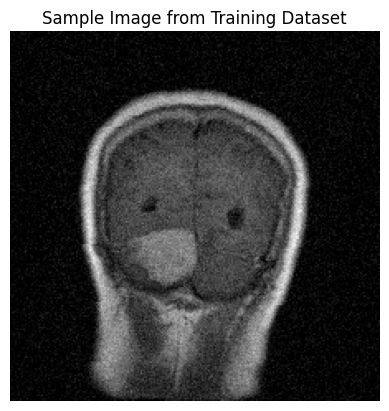

In [14]:
# Take a peek at the first sample in the training dataset
sample_image_tensor, sample_label_tensor = train_dataset[0]
print("Sample image tensor shape:", sample_image_tensor.shape)
print("Sample label tensor (one-hot):", sample_label_tensor)
print("sample label tensor shape:", sample_label_tensor.shape)

# Convert the sample image tensor back to a numpy array for visualization	
sample_image_np = sample_image_tensor.squeeze(0).numpy() * 255  # Convert back to [0, 255] range
plt.imshow(sample_image_np, cmap='gray')
plt.title("Sample Image from Training Dataset")
plt.axis('off')
plt.show()


**Task 3.3. Check your understanding (5 points)**

---

**Suitable transforms for medical images:**

* **Random noise:** Medical scans often contain slight noise due to imaging devices. Adding controlled noise during training can help the model become more robust to real-world variations.

* **Random horizontal flips:** In some cases (e.g., brain images), anatomical structures are approximately symmetrical. Applying horizontal flips can help the model generalize better and become less sensitive to orientation.

* **Small rotations (tilts):** Slight rotations simulate variations in how images are captured, improving the model’s ability to handle different viewing angles without changing the underlying anatomy.

---

**Not recommended transforms:**

* **Random cropping:** This can remove important regions, such as tumors or other critical features, leading to incorrect learning.

* **Large rotations or extreme geometric distortions:** These can alter anatomical structures in unrealistic ways, making the data medically inaccurate.

* **Vertical flips (in many cases):** Flipping images vertically can distort anatomical meaning (e.g., top vs. bottom of the body), which may confuse the model and reduce performance.


Is the training/val/test enough? Should this split have been done differently?

*Your answer here*

Without having trained or validated the baseline model yet, it is difficult to definitively conclude if the current Train/Validation/Test split ratio is optimal. However, if we find that the model is overfitting due to a lack of training data, we can artificially increase the diversity of our existing training set through on-the-fly data augmentation (e.g., applying random horizontal flips, minor rotations, and Gaussian noise). This forces the network to generalize without requiring us to change the split ratio or collect new clinical data."

**Task 3.4. Create DataLoaders for training, validation, and testing. (5 points)**

---

Feel free to set parameters.


In [15]:
# YOUR CODE HERE

train_dataloader = Data.DataLoader(train_dataset, batch_size=64, shuffle=True)
validation_dataloader = Data.DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataloader = Data.DataLoader(test_dataset, batch_size=64, shuffle=False)

## Task 4 (30 points)

---

Construct and train a convolutional neural network using `Pytorch` (check out this tutorial)(https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html)

**Task 4.1. Build the CNN architecture (10 points)**

---

You could construct your own structure of the CNN. But there are some restrictions in this task:

1. Convolution layers should be no more than 3 layers.
2. Use linear layer(s) to condese your features after the convolution layers.
3. Batch normalization is needed. Drop out is optional.
4. Use ReLU function as your activation function.

In [16]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

if torch.cuda.is_available():
  device = torch.device('cuda:0')
  print('Running on the GPU')
else:
  device = torch.device('cpu')
  print('Running on the CPU')

Running on the GPU


In [17]:
# Construct the CNN

import torch.nn as nn
import torch.nn.functional as F

class CNN(torch.nn.Module):

	def __init__(self):
		super(CNN, self).__init__()
		
		# Shared layers for all convolutional layers
		self.pool = nn.MaxPool2d(kernel_size=2, stride=2)	
		self.relu = nn.ReLU()
		self.dropout = nn.Dropout(p=0.6)
  
		# First convolutional layer: 1 input channel (grayscale), 16 output channels
		self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
		self.bn1 = nn.BatchNorm2d(16)
		
		# Second convolutional layer: 16 input channels, 32 output channels
		self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
		self.bn2 = nn.BatchNorm2d(32)
		
		# Third convolutional layer: 32 input channels, 64 output channels
		self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
		self.bn3 = nn.BatchNorm2d(64)
		
  
		# Calculate the layer size for the linear layer dynamically based on the output of the convolutional layers
		fake_image = torch.zeros(1, 1, 224, 224)  # Batch size of 1, 1 channel, 224x224 image
		fake_image = self.pool(self.relu(self.bn1(self.conv1(fake_image))))
		fake_image = self.pool(self.relu(self.bn2(self.conv2(fake_image))))
		fake_image = self.pool(self.relu(self.bn3(self.conv3(fake_image))))
		self.flattened_size = self.num_flat_features(fake_image)
		
		self.fc1 = nn.Linear(self.flattened_size, 128)
		self.fc2 = nn.Linear(128, 4)	

	def forward(self, x):

		# Convolutional layer 1
		x = self.conv1(x)
		x = self.bn1(x)
		x = self.relu(x)
		x = self.pool(x)
  
		# Convolutional layer 2
		x = self.conv2(x)
		x = self.bn2(x)
		x = self.relu(x)
		x = self.pool(x)
  
		# Convolutional layer 3
		x = self.conv3(x)
		x = self.bn3(x)
		x = self.relu(x)
		x = self.pool(x)
  
		# Flatten the output from the convolutional layers
		x = x.view(-1, self.flattened_size)
		x = self.fc1(x)
		x = self.relu(x)
		x = self.dropout(x)
		x = self.fc2(x)

		return x

	def num_flat_features(self, x):
		# YOUR CODE HERE
		return x.size(1) * x.size(2) * x.size(3)



In [18]:
# Define the loss function and optimizer
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


**Task 4.2. Train the CNN (10 points)**

---


Train the network using traing and validation dataset using your own setting (optimizer, criterion, epoch number, batch size) for training.  You must print *at least* the loss and accuracy on training and validation set in each epoch.

In [19]:
from tqdm import tqdm

def save_model(model,path_to_store_model):
    path = path_to_store_model
    torch.save(model.state_dict(), path)
    
    print(f"Model saved to {path}")
    


def train_model(num_epochs, model, train_loader, validate_loader, criterion, optimizer, path_to_store_model):
    # YOUR CODE HERE
	for epoch in range(num_epochs):
		model.train()  # Set the model to training mode
		running_loss = 0.0
		
		for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
			images, labels = images.to(device), labels.to(device)
			
			optimizer.zero_grad()  # Zero the parameter gradients
			
			outputs = model(images)  # Forward pass
   
			loss = criterion(outputs, labels)  # Compute loss
   
			loss.backward()  # Backward pass
   
			optimizer.step()  # Update parameters
   
			running_loss += loss.item()
			
		avg_loss = running_loss / len(train_loader)
		print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")
  
		# Test on the validation set after each epoch
		model.eval()  # Set the model to evaluation mode
		with torch.no_grad():
			correct = 0
			total = 0
			for images, labels in validate_loader:
				images, labels = images.to(device), labels.to(device)
				outputs = model(images)
				_, predicted = torch.max(outputs.data, 1)
				_, labels_max = torch.max(labels.data, 1)  # Get the true class indices from one-hot encoding
				total += labels.size(0)
				correct += (predicted == labels_max).sum().item()
		print(f'Validation Accuracy: {100 * correct / total:.2f}%')
  
	save_model(model, path_to_store_model)

# Train the model for 20 epochs 
train_model(num_epochs=20, model=model, train_loader=train_dataloader, validate_loader=validation_dataloader, criterion=criterion, optimizer=optimizer, path_to_store_model="NetModel.pth") 
 

Epoch 1/20: 100%|██████████| 53/53 [00:22<00:00,  2.31it/s]


Epoch [1/20], Loss: 2.4556
Validation Accuracy: 34.58%


Epoch 2/20:  43%|████▎     | 23/53 [00:08<00:11,  2.69it/s]


KeyboardInterrupt: 

**Task 4.3. Evaluate the network performance using test dataset. (5 points)**

---

In [34]:
def test(model, test_loader):
	"""
	Evaluate the model on the test set and print the accuracy.
	Load the model saved at the last epoch of training
	"""
	device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
	model = model.to(device)
 
	total = 0
	correct = 0

	# YOUR CODE HERE
	for images, labels in test_loader:
		images, labels = images.to(device), labels.to(device)
		outputs = model(images)
		_, predicted = torch.max(outputs.data, 1)
		_, labels_max = torch.max(labels.data, 1)  # Get the true class indices from one-hot encoding
		total += labels.size(0)
		correct += (predicted == labels_max).sum().item()

	print(f'Test Accuracy: {100 * correct / total:.2f}%')
 
		


**Task 4.4: Compute and print per-class accuracy and the confusion matrix on test dataset (5 points)**

---

In [ ]:

test(model, test_dataloader)

In [35]:
def test_acc_class(model, test_loader):
	"""
	Computes and prints per-class accuracy and the confusion matrix.
	Assumes test labels are one-hot encoded.
	"""
	device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
	model = model.to(device)

	# YOUR CODE HERE

	model.eval()  # Set the model to evaluation mode

	all_predicted = []
	all_labels = []

	for images, labels in test_loader:
		images, labels = images.to(device), labels.to(device)
		outputs = model(images)
		_, predicted = torch.max(outputs.data, 1)
		_, labels_max = torch.max(labels.data, 1)  # Get the true class indices from one-hot encoding
  
		all_predicted.extend(predicted.cpu().numpy())
		all_labels.extend(labels_max.cpu().numpy())
		

	
	# Calculate the confusion matrix and per-class accuracy using sklearn
	cm = sklearn.metrics.confusion_matrix(all_labels, all_predicted)
	acc_per_class = cm.diagonal() / cm.sum(axis=1)
	classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
	
	print(f" Accuracy per class: {acc_per_class}\n")
	print(f" Classes: {classes}\n")
	print(f" Confusion matrix:\n{cm}")

	plt.figure(figsize=(8, 6))
	sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
	plt.xlabel('Predicted Label')
	plt.ylabel('True Label')
	plt.title('Confusion Matrix')
	plt.show()
	

In [22]:
!mv 20_epochs.pth NetModel.pth

mv: cannot stat '20_epochs.pth': No such file or directory


 Accuracy per class: [0.99637681 0.12891986 0.55395683 0.32773109]

 Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

 Confusion matrix:
[[275   1   0   0]
 [239  37   7   4]
 [ 35  79 154  10]
 [ 47  33   0  39]]


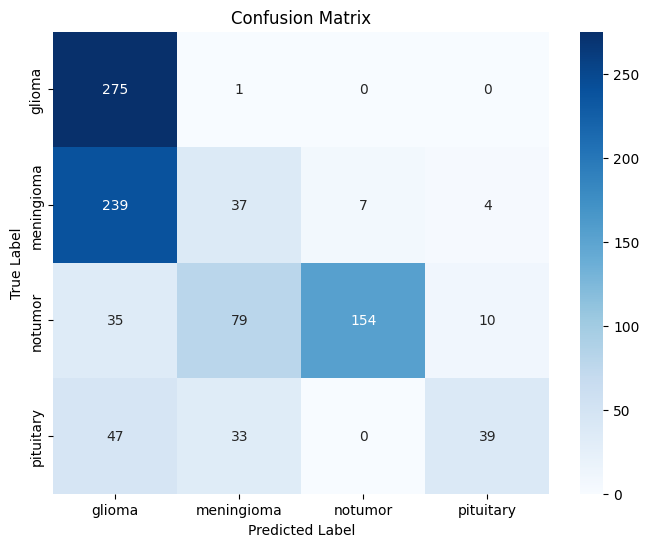

In [23]:
model = CNN()
path = "NetModel.pth"
model.load_state_dict(torch.load(path))
model.eval()

test_acc_class(model, test_dataloader)

## Task 5 (15 points)

---



**Task 5.1. Data imbalance (10 points)**

---

As we can see, the four classes are not perfectly balanced, which might introduce bias on between them. Please modify your loss function nn.CrossEntropyLoss() to take the class inbalance into consideration, and see if the accuracy on the same test set is improved or not compared to Task 5 when only the loss function is changed.

In [ ]:
# YOUR CODE HERE
# remember to refine a NEW network lile
#   model_new = CNN()
#   net_adjusted_loss = Train_model(model_new,epochs,optmizer,criterion).
#   
class MyCrossEntropyLoss(nn.Module):
    def __init__(self, weights):
        super(MyCrossEntropyLoss, self).__init__()
        self.weights = weights

    def forward(self, inputs, targets):
        # Apply log_softmax to get numerically stable log-probabilities
        log_probs = F.log_softmax(inputs, dim=1)
        
        # Extract the target indices (needed to select the correct weights)
        _, target_indices = torch.max(targets, 1)
        
        # Get the weight for every single image in the batch based on its class
        batch_weights = self.weights[target_indices]
        
        # Compute Weighted Cross Entropy:
        per_image_loss = -torch.sum(targets * log_probs, dim=1) * batch_weights
        
        #  Return the average loss for the whole batch
        return torch.mean(per_image_loss)

In [25]:
counts = train_df["label"].value_counts()
weights = counts.sum() / ( 4 * counts)
print("Class weights:", weights)

Class weights: label
glioma        0.851064
meningioma    0.861538
notumor       0.867769
pituitary     1.953488
Name: count, dtype: float64


In [26]:
#  Calculate weights based on your training distribution

class_weights_tensor = torch.from_numpy(weights.values).to(device)

#  Initialize your CUSTOM loss function
my_weighted_criterion = MyCrossEntropyLoss(weights=class_weights_tensor)

#  Define a fresh model and optimizer
model_new = CNN().to(device)
optimizer = torch.optim.Adam(model_new.parameters(), lr=0.001)

#  Train
train_model(num_epochs=20, model=model_new, train_loader=train_dataloader, validate_loader=validation_dataloader, criterion=my_weighted_criterion, optimizer=optimizer, path_to_store_model="NetModel1.pth") 



Epoch 1/20:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 1/20: 100%|██████████| 27/27 [00:22<00:00,  1.19it/s]


Epoch [1/20], Loss: 3.6136
Validation Accuracy: 28.54%


Epoch 2/20: 100%|██████████| 27/27 [00:22<00:00,  1.19it/s]


Epoch [2/20], Loss: 0.9186
Validation Accuracy: 42.71%


...

Epoch [18/20], Loss: 0.5801
Validation Accuracy: 69.38%


Epoch 19/20: 100%|██████████| 27/27 [00:23<00:00,  1.16it/s]


Epoch [19/20], Loss: 0.5963
Validation Accuracy: 73.75%


Epoch 20/20: 100%|██████████| 27/27 [00:23<00:00,  1.16it/s]


Epoch [20/20], Loss: 0.6133
Validation Accuracy: 75.21%
Model saved to NetModel1.pth


In [27]:
model_2 = CNN()
path2 = "./NetModel1.pth"
model_2.load_state_dict(torch.load(path2))
model_2.eval()
results = test(model_2, test_dataloader)

Test Accuracy: 75.94%


 Accuracy per class: [0.83695652 0.72473868 0.63669065 0.94957983]

 Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

 Confusion matrix:
[[231  38   0   7]
 [ 36 208  12  31]
 [ 14  43 177  44]
 [  5   1   0 113]]


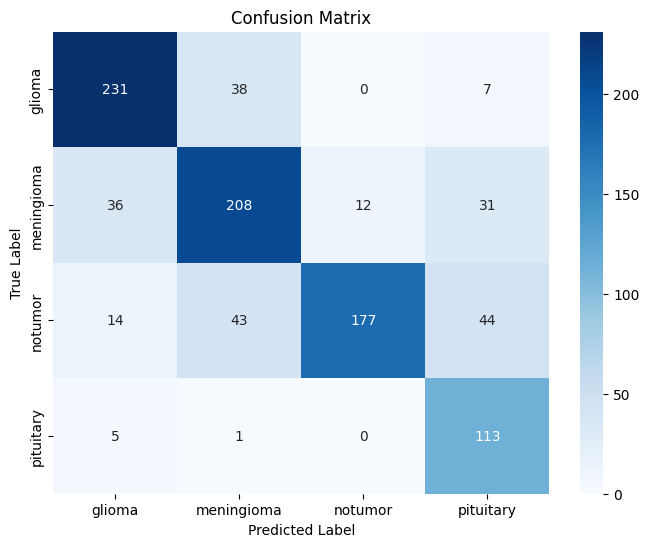

In [28]:
test_acc_class(model_2, test_dataloader)

**Task 5.2 Check your understanding (5 points)**

---

Compare the results before and after compensating the data imbalance. Did it work? And what could you find after comparing the two confusion matrices?

*The weighted CE allows to reach better accuracy for the first class. Moreover, at it can be seen from the validation set, the performance of the model is more stable.*

1. Did it work?
Yes. Compensating for data imbalance improved the model's test accuracy from 52.60% to 75.94%.

2. Comparison of the Confusion Matrices
Before (Unweighted): The model suffered from extreme majority class bias. It essentially learned to guess Glioma for almost everything (achieving 99.6% accuracy for Glioma), but completely failed on minority classes like Meningioma (12.9%) and Pituitary (32.8%).

- After (Weighted): The predictions became properly balanced. The model stopped using Glioma as a fallback guess (Glioma accuracy dropped to a more realistic 83.7%), while minority class accuracies surged (Meningioma hit 72.5% and Pituitary jumped to 94.9%). The new confusion matrix shows a strong diagonal line, showing that the model actually learned to distinguish Meningoma and Pitutary tumors better.

Also as noted in the text above, the validations seem to be more stable and steadily increasing with iteration.

## Task 6 (20 points)

---



**Task 6.1. Transfer learning and finetuning (15 points)**

---

Use pre-trained Res18 Model and finetune it for 4 classes in pytorch using the provided data. Train for 10 epoches, and in the first 5 epoches, do not freeze the parameters and train the whold model; in the last 5 epoches, freeze the part of Res18 and only train your classifier (last several fc layers). To achieve this, you may need to define a new training function Train_model_new()

Show performance using accuracy and confusion matrix.
> Pleae note you will need to also import the pre-process function for the model <br>
> Nice tutorial to understand tranfer learning in `Pytorch`: https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

###### Maybe use pre-trained network as feature extractor for better accuracy (this reference for Keras also makes sense for Pytorch)
https://machinelearningmastery.com/how-to-use-transfer-learning-when-developing-convolutional-neural-network-models/

In [22]:
# YOUR CODE HERE
import torchvision
resnet18 = torchvision.models.resnet18(weights="DEFAULT")

resnet18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [23]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class MRIDatasetRGB(Dataset):
	"""
	PyTorch dataset class that loads RGB images for ResNet-18 transfer learning.
	"""
	def __init__(self, df, transform=None, target_transform=None):
		self.df = df
		self.transform = transform
		self.target_transform = target_transform	

		self.encoding = {
			"glioma": 0,
			"meningioma": 1,
			"notumor": 2,
			"pituitary": 3
		}
		


	def __len__(self):
		return len(self.df)


	def __getitem__(self, idx):
		img_path = self.df.iloc[idx]['image_path']
		label_str = self.df.iloc[idx]['label']

		image = Image.open(img_path).convert("RGB")

		if self.transform:
			image_tensor = self.transform(image)
		else:
			image = image.resize((224, 224))
			image_tensor = torch.from_numpy(np.array(image)).permute(2, 0, 1).float() / 255.0


		if self.target_transform:
			label = self.target_transform(label)
		else:
			# Create a one hot encoding vector for the label
			label = self.encoding[label_str]
			label_tensor = torch.zeros(4, dtype=torch.float32)
			label_tensor[label] = 1.0
			label_tensor = label_tensor.to(device)


		return image_tensor, label_tensor

In [24]:
#
# YOUR CODE HERE
resnet_transform = transforms.Compose([
	transforms.Resize((224, 224)), # Resize to 224x224
	transforms.ToTensor(), # Convert to tensor and scale pixel values to [0, 1]
	transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize using ImageNet mean and std
])

train_dataset = MRIDatasetRGB(
    df=train_df,              
    transform=resnet_transform 
)

val_dataset = MRIDatasetRGB(
    df=val_df,                
    transform=resnet_transform
)

test_dataset = MRIDatasetRGB(
    df=test_df,              
    transform=resnet_transform
)

train_dataloader = Data.DataLoader(train_dataset, batch_size=64, shuffle=True)
validation_dataloader = Data.DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataloader = Data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print(len(train_dataset), len(val_dataset), len(test_dataset))

3360 480 960


In [25]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

def build_resnet18_model(num_classes=4):
    """
    Loads a pre-trained ResNet-18 model and modifies the final 
    fully connected layer to output the specified number of classes.
    """
    # Load the pre-trained ResNet-18 model with default weights
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    
    # Get the number of input features going into the original fully connected (fc) layer
    num_ftrs = model.fc.in_features
    
    # Replace the final layer with a new Linear layer that outputs num_classes
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    return model

In [29]:
from tqdm import tqdm
import torch


def get_device():
    try:
        import torch_xla.core.xla_model as xm
        return xm.xla_device()  # TPU
    except ImportError:
        if torch.cuda.is_available():
            return torch.device("cuda")
        elif torch.backends.mps.is_available():
            return torch.device("mps")
        else:
            return torch.device("cpu")

device = get_device()
print(device)


def Train_model_new(model, train_loader, validate_loader, criterion, optimizer, path_to_store_model, total_epochs=10, freeze_after=5):
	for e in range(total_epochs):
  
		if e == freeze_after:
			print("Freezing convolutional layers...")
			for param in model.parameters(): 
				param.requires_grad = False
			for param in model.fc.parameters():	# Make only the final fully connected layer trainable
				param.requires_grad = True

		model = model.to(device)
		model.train()  # Set the model to training mode
		running_loss = 0.0		# Stores the running loss for the current epoch
		for image, labels in tqdm(train_loader, desc=f"Epoch {e+1}/{total_epochs}"):
			image, labels = image.to(device), labels.to(device)
			
			optimizer.zero_grad()  # Zero the parameter gradients
			
			outputs = model(image)  # Forward pass
   
			loss = criterion(outputs, labels)  # Compute loss
   
			loss.backward()  # Backward pass
   
			optimizer.step()  # Update parameters
   
			running_loss += loss.item()

		avg_loss = running_loss / len(train_loader)
		print(f"Epoch [{e+1}/{total_epochs}], Loss: {avg_loss:.4f}")
		
		# Test on the validation set after each epoch
		with torch.no_grad():
			correct = 0
			total = 0
			for image, labels in validate_loader:
				image, labels = image.to(device), labels.to(device)
				
				outputs = model(image) # Compute the forward pass
    
				correct_tensor = torch.argmax(outputs.data, 1) == torch.argmax(labels.data, 1)
				correct += correct_tensor.sum().item()
				total += labels.size(0)
		print(f'Validation Accuracy: {100 * correct / total:.2f}%')
	save_model(model, path_to_store_model)
				

cuda


In [30]:
model_resnet = build_resnet18_model(num_classes=4)

# YOUR CODE HERE

# Train the model with the new training function that includes dynamic freezing
best_model = Train_model_new(
	model=model_resnet,
	train_loader=train_dataloader,
	validate_loader=validation_dataloader,
	criterion=nn.CrossEntropyLoss(),
	optimizer=torch.optim.Adam(model_resnet.parameters(), lr=0.001),
	path_to_store_model="best_resnet_model.pth",
	total_epochs=10,
	freeze_after=5
)

Epoch 1/10: 100%|██████████| 53/53 [00:23<00:00,  2.22it/s]


Epoch [1/10], Loss: 0.3968
Validation Accuracy: 92.92%


Epoch 2/10: 100%|██████████| 53/53 [00:24<00:00,  2.21it/s]


Epoch [2/10], Loss: 0.1513
Validation Accuracy: 91.67%


Epoch 3/10: 100%|██████████| 53/53 [00:24<00:00,  2.19it/s]


...

Epoch [8/10], Loss: 0.0530
Validation Accuracy: 93.54%


Epoch 9/10: 100%|██████████| 53/53 [00:18<00:00,  2.90it/s]


Epoch [9/10], Loss: 0.0519
Validation Accuracy: 93.75%


Epoch 10/10: 100%|██████████| 53/53 [00:18<00:00,  2.90it/s]


Epoch [10/10], Loss: 0.0452
Validation Accuracy: 94.79%
Model saved to best_resnet_model.pth


In [36]:
# Load best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
path = "best_resnet_model.pth"
model_resnet.load_state_dict(torch.load(path, map_location=device))
model_resnet.to(device)
model_resnet.eval()

# Accuracy
test(model_resnet, test_dataloader)


Test Accuracy: 96.35%


 Accuracy per class: [0.98550725 0.93379791 0.97122302 0.94117647]

 Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

 Confusion matrix:
[[272   2   2   0]
 [  4 268   6   9]
 [  2   1 270   5]
 [  2   4   1 112]]


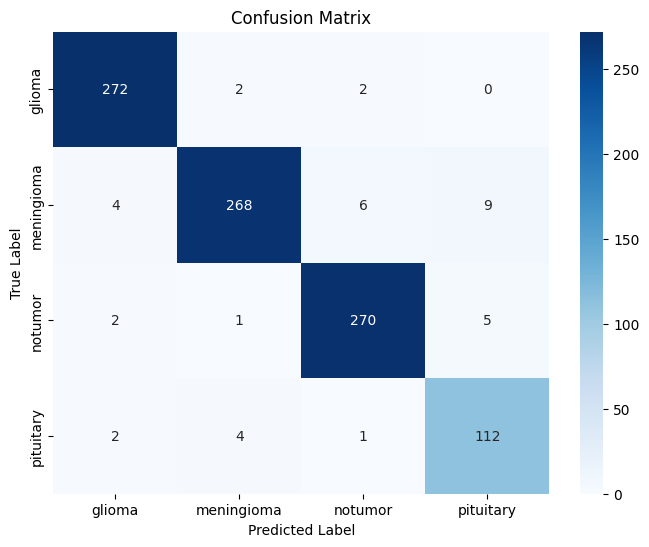

In [56]:
test_acc_class(model_resnet, test_dataloader)

**Task 6.2. Check your understanding (5 points)**

---

Compare the results (accuracy, loss etc.) for model performance with and without transfer learning. Which one is better? How? Why?

*The model when finetuned reached a better accuracy for each of the classes considered than the simple CNN model used in the previous experiments. This result is expected as the finetuned model was pretrained on a significant amount of data that helped the model to reach higher accuracy.*

Yes, using transfer learning significantly improved the model across all metrics compared to the custom CNN. By achieving over 95% test accuracy, the model can even be potential be used for industrial application in classifying actual tumor types. Furthermore, the transfer learning model converged incredibly fast, reaching an impressive ~92% accuracy right from the very first epoch.

The primary reason it performs so much better is that ResNet 18 leverages pre trained weights. Because the network was previously trained on millions of diverse, real world images, its convolutional layers are already highly optimized for fundamental computer vision tasks like boundary detection, texture recognition, and complex feature extraction. Instead of having to learn how to "see" from scratch using only our limited MRI dataset, the model simply takes its deep, pre-existing visual knowledge and fine-tunes it to recognize the specific shapes and patterns of brain tumors.

## Task 7 (Bonus) (10 points)

---

Increase the depth of your network in Task6 to 15 layers. Test it and compare the performance to the one in Task6, does deeper netowork work better? And then add res blocks to see what will happen, answer what problem the res blocks are designed to solve.

In [ ]:
class PlainDeepCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(PlainDeepCNN, self).__init__()
        # First layer accepts 3 input channels instead of 1
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            
            nn.AdaptiveAvgPool2d((1, 1)) 
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [64]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # The Shortcut (Skip Connection)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x) # Add the original input back to the output
        out = F.relu(out)
        return out

class CustomDeepResNet(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomDeepResNet, self).__init__()
        self.in_channels = 32
        
        # Initial Layer (1 channel input for grayscale)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        
        # 7 Residual Blocks (14 layers) 
        self.layer1 = self._make_layer(32, 2, stride=1)
        self.layer2 = self._make_layer(64, 2, stride=2)
        self.layer3 = self._make_layer(128, 2, stride=2)
        self.layer4 = self._make_layer(256, 1, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(ResBlock(self.in_channels, out_channels, s))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

Training Plain 15-Layer CNN...


Epoch 1/10:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 53/53 [02:19<00:00,  2.63s/it]


Epoch [1/10], Loss: 0.8689
Validation Accuracy: 32.08%


Epoch 2/10: 100%|██████████| 53/53 [02:17<00:00,  2.59s/it]


...

Epoch [8/10], Loss: 0.4321
Validation Accuracy: 68.12%


Epoch 9/10: 100%|██████████| 53/53 [02:18<00:00,  2.62s/it]


Epoch [9/10], Loss: 0.4246
Validation Accuracy: 43.12%


Epoch 10/10: 100%|██████████| 53/53 [02:19<00:00,  2.64s/it]


Epoch [10/10], Loss: 0.3931
Validation Accuracy: 76.88%
Model saved to plain_deep.pth
 Accuracy per class: [0.94927536 0.66898955 0.84172662 0.85714286]

 Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

 Confusion matrix:
[[262  11   0   3]
 [ 67 192  12  16]
 [  8  24 234  12]
 [  6   9   2 102]]


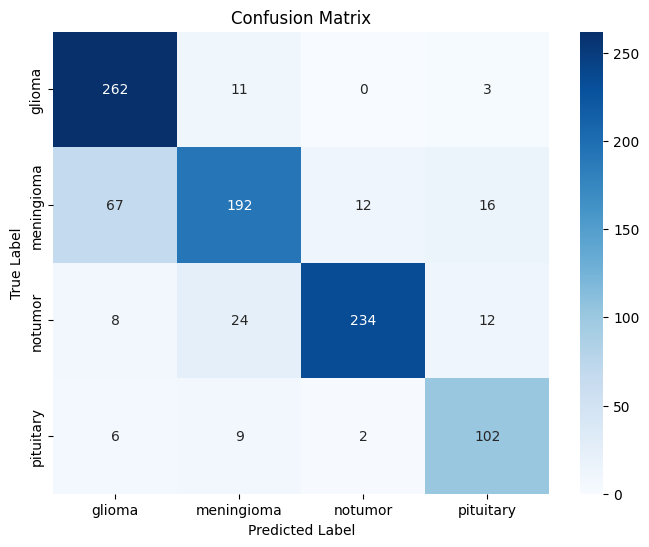


Training 15-Layer ResNet...


Epoch 1/10:   0%|          | 0/53 [00:00<?, ?it/s]


RuntimeError: Given groups=1, weight of size [32, 1, 3, 3], expected input[64, 3, 224, 224] to have 1 channels, but got 3 channels instead

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Test Plain Deep CNN 
print("Training Plain 15-Layer CNN...")
plain_model = PlainDeepCNN().to(device)
optimizer_plain = torch.optim.Adam(plain_model.parameters(), lr=0.001)

train_model(10, plain_model, train_dataloader, validation_dataloader, criterion, optimizer_plain, "plain_deep.pth")
test_acc_class(plain_model, test_dataloader)



Training 15-Layer ResNet...


Epoch 1/10: 100%|██████████| 53/53 [03:34<00:00,  4.05s/it]


Epoch [1/10], Loss: 0.7699
Validation Accuracy: 72.08%


Epoch 2/10: 100%|██████████| 53/53 [03:37<00:00,  4.10s/it]


Epoch [2/10], Loss: 0.6316
Validation Accuracy: 59.17%


...

Epoch [8/10], Loss: 0.4483
Validation Accuracy: 65.21%


Epoch 9/10: 100%|██████████| 53/53 [03:40<00:00,  4.16s/it]


Epoch [9/10], Loss: 0.4264
Validation Accuracy: 63.54%


Epoch 10/10: 100%|██████████| 53/53 [03:40<00:00,  4.16s/it]


Epoch [10/10], Loss: 0.3980
Validation Accuracy: 71.88%
Model saved to custom_res.pth
 Accuracy per class: [0.65217391 0.66202091 0.95683453 0.93277311]

 Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

 Confusion matrix:
[[180  68  13  15]
 [  4 190  25  68]
 [  1   5 266   6]
 [  0   5   3 111]]


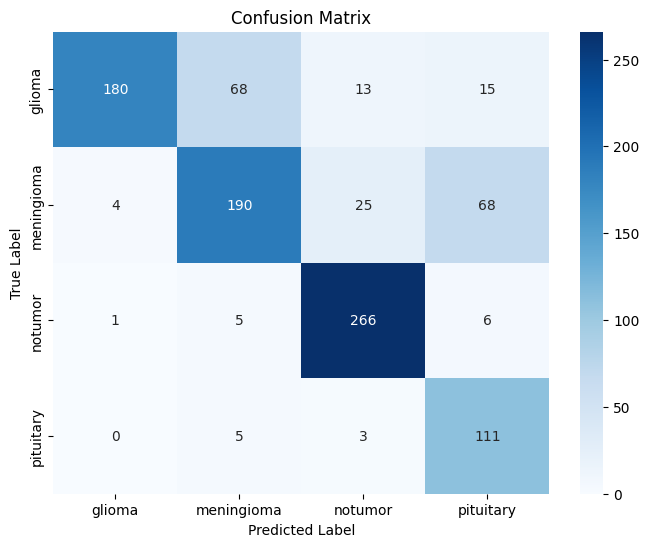

In [65]:
#lNOTE: I Fixed the code and re-run it here. It would take a lot of time to train the cell again. 
# The first model trained successfully and now I am training the custom ResNet in a new cell to save time.
# Test Custom ResNet
print("\nTraining 15-Layer ResNet...")
res_model = CustomDeepResNet().to(device)
optimizer_res = torch.optim.Adam(res_model.parameters(), lr=0.001)

train_model(10, res_model, train_dataloader, validation_dataloader, criterion, optimizer_res, "custom_res.pth")
test_acc_class(res_model, test_dataloader)

Compared to the 3-layer CNN from Task 4 (Not 6 :o ), the plain 15 layer network I implemented showed only a marginal (around 76c% peak validation accuray). This plateau in performance is primarily due to the vanishing gradient problem. As the network depth increases, the repeated floating-point multiplications during backpropagation cause the gradients to shrink exponentially. Consequently, the earlier layers of the network receive minimal weight updates and essentially stop learning, which prevents the model from benefiting from the increased depth.

Also the 15-layer custom ResNet achieved little to no noticeable improvement in accuracy. The addition of residual blocks (skip connections)  could mitigated the vanishing gradient issue by providing alternate, unobstructed paths for the gradients to flow backward, allowing the deeper network to train effectively. However, it still could not match the high accuracy metrics of the transfer learning model from Task 6. This is because the transfer learning model was pre-trained on a massive, diverse dataset (ImageNet), allowing it to leverage highly optimized, pre-learned visual features rather than having to learn how to extract features completely from scratch.